# Convolutional Neural Network zur Ziffernerkennung
## Implementierung mit PyTorch am Beispiel MNIST



**Autor:** Christian Jakubzig  
**Version:** 1.0  
**Datum:** Februar 2026  
**Kurs:** Master of Science Library Informatics – TH Wildau



### Beschreibung
Dieses Notebook dokumentiert die schrittweise Implementierung 
eines CNN zur Erkennung handgeschriebener Ziffern (0–9).

## Inhaltsverzeichnis

1. [Setup & Imports](#imports)\
1.1 [Verwendete Bibliotheken](#library)
2. [Datensatz laden](#data)\
2.1 [Transformationspipeline](#transform)\
2.2 [Trainingsdaten laden](#train)\
2.3 [Testdaten laden](#test)\
2.4 [Beispielbilder visualisieren](#beispielbilder)
3. [Gerät konfigurieren](#device)
4. [Modell-Architektur](#model)
5. [Modell-Architektur](#model)
6. [Dimensionen im Forward Pass](#dims)
7. [Architektur visualisieren](#arch)
8. [Loss & Optimizer](#loss)
9. [Training](#training)
10. [Ergebnisse](#results)

## 1. Setup & Imports <a id='imports'></a>

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchinfo import summary
from torchview import draw_graph

%matplotlib inline

### 1.1 Verwendete Bibliotheken <a id='library'></a>

**Kernbibliotheken:**
- `torch` ist die Basis des gesamten Projekts – es stellt Tensoren 
bereit, also die mehrdimensionalen Datenstrukturen in denen unsere 
Bilder und Gewichte gespeichert werden, und ermöglicht die 
GPU-Beschleunigung über CUDA. [[1]](#quellen)
- `torch.nn` stellt fertige Bausteine für neuronale Netze bereit - wie Conv2d oder Linear - die lernbare Parameter (Weights und Biases) besitzen und sich während des Trainings anpassen. [[2]](#quellen)
- `torch.nn.functional` enthält Funktionen die selbst keine 
lernbaren Parameter besitzen und sich während des Trainings 
nicht verändern - wie z.B. ReLU oder MaxPool. Sie übernehmen 
die Verarbeitung der Daten zwischen den lernbaren Schichten. [[3]](#quellen)

**Datenvorbereitung:**
- `torchvision.datasets` stellt fertige Datensätze bereit, 
darunter MNIST der in diesem Projekt verwendet wird. [[4]](#quellen)
- `torchvision.transforms` bereitet die Bilder für das Training 
vor, z.B. Umwandlung in Tensoren und Normalisierung der Pixelwerte. [[5]](#quellen)

**Training:**
- `torch.optim` stellt Algorithmen bereit mit denen die Gewichtsanpassung 
im Netz gesteuert wird. [[6]](#quellen)

**Hilfsmittel:**
- `matplotlib`, `torchinfo` und `torchview` 
werden für Visualisierungen und die Darstellung des 
Trainingsfortschritts verwendet.

## 2. Datensatz laden <a id='data'></a>

MNIST ist ein Datensatz von 70.000 graustufigen 28x28 Pixel Bildern die handgeschriebene Ziffern von 0 bis 9 zeigen. Alle Bilder sind mit einem Label versehen, welches die richtige Ziffer angibt. Der Datensatz ist freiverfügbar und wird gerne genutzt um neuronale Netze zu testen oder als Lehrmaterial. 60.000 dieser Bilder sind für das Training des Netzwerks vorgesehen die restlichen 10.000 um das Netz zu testen. ([vgl. Wikipedia, 2022](#quellen))

### 2.1 Transformationspipeline <a id='transform'></a>

Die Daten aus den MNIST Datensatz sind in ihrer derzeitigen Form für das neuronale Netz noch nicht geeignet. Zunächst müssen wir die einzelnen Bilder konvertieren. An dieser Stelle definieren wir die erforderlichen Schritte die wir später beim laden der Bilder ausführen. Mit *transforms.Compose erstellen wir eine Pipeline in der wir zwei Schritte hintereinander ausführen. *transforms.ToTensor()* transformiert unsere Daten von 28x28 Pixel Bilder in mehrdimensionale Tensoren. Mit *transforms.Normalize* normalisieren wir die Daten. 

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

### 2.2 Trainingsdaten laden <a id='train'></a>

- `batch_size=64` – Wieviele Bilder gleichzeitig verarbeitet werden
- `shuffle=True` – Daten werden in zufälliger Reihenfolge geladen (verhindert Auswendiglernen von Mustern)
- `num_workers=1` – Anzahl CPU-Prozesse die Daten im Hintergrund laden
- `pin_memory=True` – Beschleunigt den Transfer CPU→GPU

In [3]:
train_data = torch.utils.data.DataLoader(
    datasets.MNIST('data', train=True, download=True, transform=transform),
    batch_size=64,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
)

### 2.3 Testdaten laden <a id='test'></a>

Wichtige Unterschiede:
- `train=False` – Lädt die 10.000 Testbilder
- `shuffle=False` – Keine Zufallsreihenfolge (für reproduzierbare Ergebnisse)

In [4]:
test_data = torch.utils.data.DataLoader(
    datasets.MNIST('data', train=False, download=True, transform=transform),
    batch_size=64,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)

### 2.4 Beispielbilder visualisieren <a id='beispielbilder'></a>

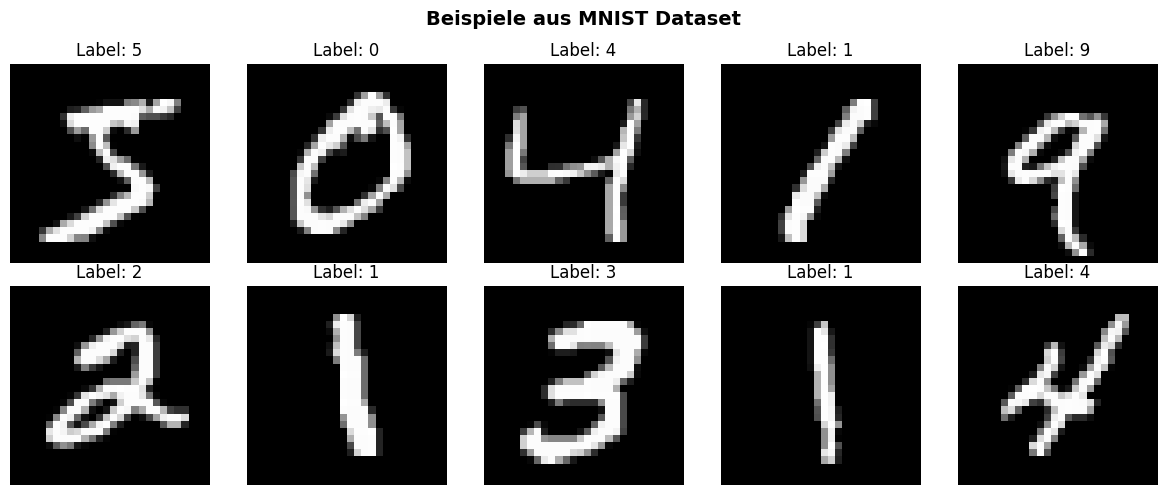

Training: 60000 Bilder
Test: 10000 Bilder
Batch Size: 64


In [5]:
# Schauen wir uns ein paar MNIST Bilder an
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    # Ein Bild aus dem Dataset holen
    img, label = train_data.dataset[i]
    
    # Von Tensor zu NumPy für Matplotlib
    img_np = img.squeeze().numpy()
    
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=12)
    ax.axis('off')

plt.suptitle('Beispiele aus MNIST Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Training: {len(train_data.dataset)} Bilder")
print(f"Test: {len(test_data.dataset)} Bilder")
print("Batch Size: 64")

## 3. Device konfigurieren <a id='device'></a>

GPU nutzen falls verfügbar, sonst CPU.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Verwende: {device}')

Verwende: cuda


## 4. Modell-Architektur <a id='model'></a>

### 4.1 Layer-Definitionen (`__init__`)

Hier definieren wir die Architektur unseres Netzes - welche Layer existieren und welche Parameter sie haben.

**Convolutional Layers (Feature Extraction):**
- `conv1`: Erster Conv-Layer mit 1 Input-Kanal (Graustufenbild) und 10 Output-Kanälen (Feature Maps). Verwendet einen 5×5 Filter.
- `conv2`: Zweiter Conv-Layer verarbeitet die 10 Feature Maps von conv1 und erzeugt 20 neue Feature Maps mit einem 5×5 Filter.
- `Dropout2d`: Schaltet zufällig Neuronen während des Trainings aus um Overfitting zu verhindern.

**Fully Connected Layers (Klassifikation):**
- `fc1`: Erster FC-Layer verdichtet die 320 Features (20×4×4 nach den Conv-Layern) auf 60 Neuronen.
- `fc2`: Ausgabe-Layer mit 10 Neuronen - eines für jede Ziffer (0-9).

### 4.2 Forward Pass (`forward()`)

Der Forward Pass zeigt wie die Daten durch das Netz fließen:

**Feature Extraction (Convolutional Teil):**
1. Conv1 + MaxPool + ReLU → Erste Features extrahieren
2. Conv2 + Dropout + MaxPool + ReLU → Komplexere Features lernen

**Klassifikation (Fully Connected Teil):**
3. Flatten → 3D-Tensor (4×4×20) wird zu 1D-Vektor (320)
4. FC1 + ReLU → Feature-Verdichtung
5. FC2 → Ausgabe (10 Ziffern)


In [19]:
class Netz(nn.Module):
    def __init__(self):
        super(Netz, self).__init__()
        self.convl = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conf_dropout = nn.Dropout2d()
        self.fcl1 = nn.Linear(320, 60)
        self.fcl2 = nn.Linear(60, 10)

    def forward(self, x):
        x = self.convl(x)
        x = F.max_pool2d(x, 2)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.conf_dropout(x)
        x = F.max_pool2d(x, 2)
        x = F.relu(x)
        x = x.view(-1, 320)
        x = F.relu(self.fcl1(x))
        x = self.fcl2(x)
        return x

In [20]:
model = Netz().to(device)

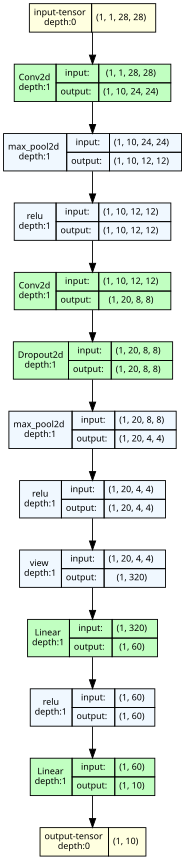

In [21]:
model_graph = draw_graph(
    model, 
    input_size=(1, 1, 28, 28),
    expand_nested=True,
    graph_name='CNN Architecture'
)
model_graph.visual_graph

In [22]:
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.8)

In [23]:
dummy = torch.zeros(1, 1, 28, 28).to(device)

out = model(dummy)

summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Netz                                     [1, 10]                   --
├─Conv2d: 1-1                            [1, 10, 24, 24]           260
├─Conv2d: 1-2                            [1, 20, 8, 8]             5,020
├─Dropout2d: 1-3                         [1, 20, 8, 8]             --
├─Linear: 1-4                            [1, 60]                   19,260
├─Linear: 1-5                            [1, 10]                   610
Total params: 25,150
Trainable params: 25,150
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.49
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.10
Estimated Total Size (MB): 0.16

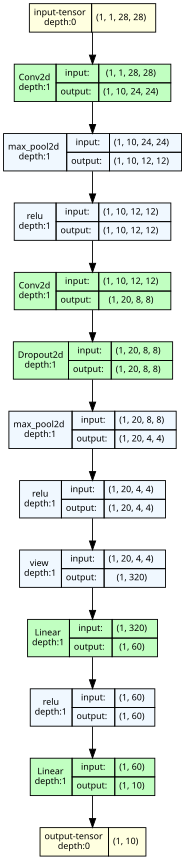

In [24]:
model_graph = draw_graph(model, input_size=(1, 1, 28, 28))
model_graph.visual_graph

In [25]:
print("🧠 Netzwerk Architektur:\n")
print(model)
print("\n" + "="*60)

# Parameter zählen
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nParameter:")
print(f"Gesamt: {total_params:,}")
print(f"Trainierbar: {trainable_params:,}")

## Layer-Größen durchrechnen
#print(f"\n📐 Dimensionen im Forward Pass:")
#print(f"   Input:        [batch, 1, 28, 28]")
#print(f"   Nach Conv1:   [batch, 10, 24, 24]  (28-5+1=24)")
#print(f"   Nach Pool1:   [batch, 10, 12, 12]  (24/2=12)")
#print(f"   Nach Conv2:   [batch, 20, 8, 8]    (12-5+1=8)")
#print(f"   Nach Pool2:   [batch, 20, 4, 4]    (8/2=4)")
#print(f"   Nach Flatten: [batch, 320]         (20*4*4=320)")
#print(f"   Nach FC1:     [batch, 60]")
#print(f"   Output:       [batch, 10]")

🧠 Netzwerk Architektur:

Netz(
  (convl): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (conf_dropout): Dropout2d(p=0.5, inplace=False)
  (fcl1): Linear(in_features=320, out_features=60, bias=True)
  (fcl2): Linear(in_features=60, out_features=10, bias=True)
)


Parameter:
Gesamt: 25,150
Trainierbar: 25,150


In [26]:
def train(epoch):
    model.train()
    for batch_id, (data, target) in enumerate(train_data):
        data = data.cuda()
        target = target.cuda()
        # Variable() entfernt - nicht mehr nötig
        optimizer.zero_grad()
        out = model(data)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        print(
            "Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
                epoch,
                batch_id * len(data),
                len(train_data.dataset),
                100.0 * batch_id / len(train_data),
                loss.item(),
            )
        )

In [27]:
def test():
    model.eval()
    loss = 0
    correct = 0
    # torch.no_grad() statt volatile
    with torch.no_grad():
        for data, target in test_data:
            data = data.cuda()
            target = target.cuda()
            out = model(data)
            # reduction='sum' statt size_average=False, .item() statt .data[0]
            loss += F.cross_entropy(out, target, reduction='sum').item()
            prediction = out.data.max(1, keepdim=True)[1]
            correct += prediction.eq(target.data.view_as(prediction)).cpu().sum()
    loss = loss / len(test_data.dataset)
    print("Durchschnittsloss: ", loss)
    print("Genauigkeit: ", 100.0 * correct / len(test_data.dataset))

In [ ]:
for epoch in range(1, 10):
    train(epoch)
    test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.306482
Train Epoch: 1 [64/60000 (0%)]	Loss: 2.286754
Train Epoch: 1 [128/60000 (0%)]	Loss: 2.263920
Train Epoch: 1 [192/60000 (0%)]	Loss: 2.272976
Train Epoch: 1 [256/60000 (0%)]	Loss: 2.251654
Train Epoch: 1 [320/60000 (1%)]	Loss: 2.227047
Train Epoch: 1 [384/60000 (1%)]	Loss: 2.203317
Train Epoch: 1 [448/60000 (1%)]	Loss: 2.193167
Train Epoch: 1 [512/60000 (1%)]	Loss: 2.094925
Train Epoch: 1 [576/60000 (1%)]	Loss: 1.981858
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.880142
Train Epoch: 1 [704/60000 (1%)]	Loss: 1.898785
Train Epoch: 1 [768/60000 (1%)]	Loss: 2.199544
Train Epoch: 1 [832/60000 (1%)]	Loss: 1.642900
Train Epoch: 1 [896/60000 (1%)]	Loss: 1.977842
Train Epoch: 1 [960/60000 (2%)]	Loss: 1.812259
Train Epoch: 1 [1024/60000 (2%)]	Loss: 1.384741
Train Epoch: 1 [1088/60000 (2%)]	Loss: 1.454332
Train Epoch: 1 [1152/60000 (2%)]	Loss: 1.155554
Train Epoch: 1 [1216/60000 (2%)]	Loss: 1.281493
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.938370
Train Epoch

## Quellen <a id='quellen'></a>

[1] PyTorch (2025). *torch*. https://pytorch.org/docs/stable/torch.html (letzter Zugriff 17.02.2025)

[2] PyTorch (2025). *torch.nn*. https://docs.pytorch.org/docs/stable/nn.html (letzter Zugriff 17.02.2025)

[3] PyTorch (2025). *torch.nn.functional*. https://docs.pytorch.org/docs/stable/nn.functional.html (letzter Zugriff 17.02.2025)

[4] PyTorch (2017). *torchvision.datasets*. https://docs.pytorch.org/vision/stable/datasets.html (letzter Zugriff 17.02.2025)

[5] PyTorch (2017). *torchvision.transforms*. https://docs.pytorch.org/vision/0.8/transforms.html (letzter Zugriff 17.02.2025)

[6] PyTorch (2025). *torch.optim*. https://docs.pytorch.org/docs/stable/optim.html (letzter Zugriff 17.02.2025)

[7] Wikipedia (2022). *MNIST-Datenbank*. https://de.wikipedia.org/wiki/MNIST-Datenbank (letzter Zugriff 17.02.2025)
